In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
# --- Mackey-Glass Generator ---
def mackey_glass(t_max, tau=17, delta_t=1, beta=0.2, gamma=0.1, n=10, x0=1.2):
    t_len = int(t_max / delta_t)
    x = np.zeros(t_len)
    x[0] = x0
    for t in range(1, t_len):
        if t - tau >= 0:
            x[t] = x[t - 1] + delta_t * (
                beta * x[t - tau] / (1 + x[t - tau] ** n) - gamma * x[t - 1]
            )
        else:
            x[t] = x[t - 1] - delta_t * gamma * x[t - 1]
    return x

# --- Parameters ---
t_max = 400
delta_t = 1
train_ics_left = np.linspace(1.0, 1.19, 20)
train_ics_right = np.linspace(1.21, 1.4, 20)
train_ics = np.concatenate((train_ics_left, train_ics_right))
test_ic = 1.2
timesteps = np.arange(0, t_max, delta_t)

# --- Generate training data ---
X_list, y_list = [], []
for ic in train_ics:
    x = mackey_glass(t_max=t_max, x0=ic)
    norm_t = timesteps / t_max
    features = np.stack([np.full_like(norm_t, ic), norm_t], axis=1)
    X_list.append(features)
    y_list.append(x)

X = np.vstack(X_list)
y = np.concatenate(y_list)

# --- Generate test data ---
x_test = mackey_glass(t_max=400, x0=test_ic)
norm_t_test = timesteps / t_max
X_test = np.stack([np.full_like(norm_t_test, test_ic), norm_t_test], axis=1)
y_test = x_test

# --- Normalize features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# --- Prepare torch datasets ---
X_tensor = torch.tensor(X_scaled, dtype=torch.float32).reshape(len(train_ics), t_max, 2)
y_tensor = torch.tensor(y, dtype=torch.float32).reshape(len(train_ics), t_max)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(0)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(0)

train_dataset = TensorDataset(X_tensor, y_tensor)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)


In [3]:
# --- GRU model (was LSTM) ---
class GRUNet(nn.Module):
    def __init__(self, input_size=2, hidden_size=128, num_layers=3):
        super(GRUNet, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.linear(out).squeeze(-1)
        return out

Epoch 0: Loss = 3.1092
Epoch 10: Loss = 0.5743
Epoch 20: Loss = 0.4739
Epoch 30: Loss = 0.3622
Epoch 40: Loss = 0.1929
Epoch 50: Loss = 0.1451
Epoch 60: Loss = 0.2101
Epoch 70: Loss = 0.0810
Epoch 80: Loss = 0.0887
Epoch 90: Loss = 0.0696

Test RMSE: 0.0506
Test R²:   0.9588


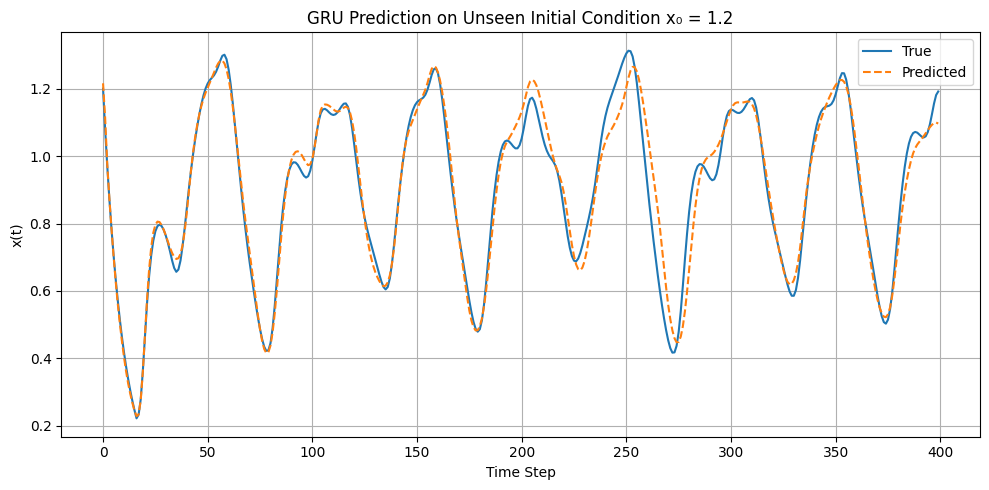

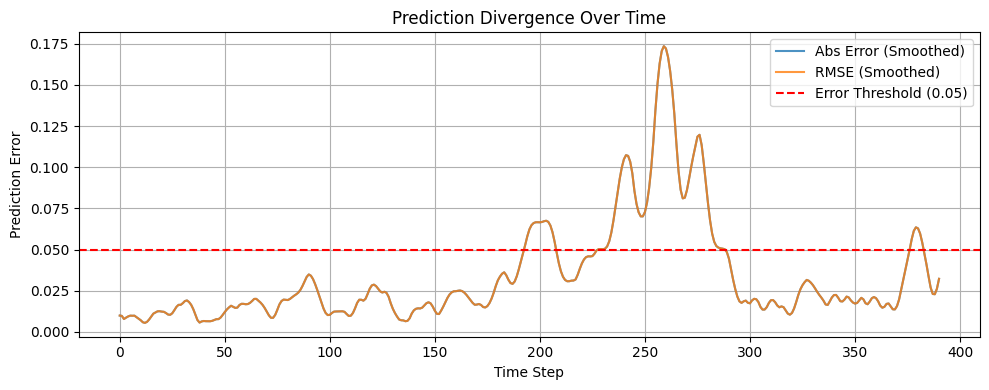

Prediction horizon at threshold 0.05: 203 steps


In [4]:
model = GRUNet()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# --- Train the model ---
epochs = 100
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        output = model(xb)
        loss = criterion(output, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss = {total_loss:.4f}")

# --- Predict on test IC ---
model.eval()
with torch.no_grad():
    pred_test = model(X_test_tensor).squeeze(0).numpy()

rmse = np.sqrt(mean_squared_error(y_test, pred_test))
r2 = r2_score(y_test, pred_test)
print(f"\nTest RMSE: {rmse:.4f}")
print(f"Test R²:   {r2:.4f}")

# --- Plot results ---
plt.figure(figsize=(10, 5))
plt.plot(y_test, label='True')
plt.plot(pred_test, label='Predicted', linestyle='--')
plt.title(f"GRU Prediction on Unseen Initial Condition x₀ = {test_ic}")
plt.xlabel("Time Step")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Divergence
errors = np.abs(pred_test - y_test)            # abs error
rmse_window = np.sqrt((pred_test - y_test)**2) # RMSE error

# Optional: smooth with moving average for clarity
def moving_avg(x, w=10):
    return np.convolve(x, np.ones(w)/w, mode='valid')

window_size = 10
smoothed_error = moving_avg(errors, w=window_size)
smoothed_rmse = moving_avg(rmse_window, w=window_size)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(smoothed_error, label="Abs Error (Smoothed)", alpha=0.8)
plt.plot(smoothed_rmse, label="RMSE (Smoothed)", alpha=0.8)
plt.axhline(y=0.05, color='r', linestyle='--', label='Error Threshold (0.05)')
plt.title("Prediction Divergence Over Time")
plt.xlabel("Time Step")
plt.ylabel("Prediction Error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

threshold = 0.05
divergence_time = np.argmax(smoothed_error > threshold) + window_size
print(f"Prediction horizon at threshold {threshold}: {divergence_time} steps")
